In [1]:
import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt

In [2]:
import glob

def load_folder(pattern: str) -> list[pd.DataFrame]:
    return [pd.read_csv(p, low_memory=False) for p in sorted(glob.glob(pattern))]

futureeval_all    = load_folder("data/futureeval/*.csv")
main_site_all     = load_folder("data/main_site/*.csv")
metaculus_cup_all = load_folder("data/metaculus_cup/*.csv")
minibench_all     = load_folder("data/minibench/*.csv")
pros_all          = load_folder("data/pros/*.csv")

for df in minibench_all:
    df['minibench_type'] = df['is_new_minibench'].map({True: 'new_minibench', False: 'old_minibench'})
for df_list in [futureeval_all, main_site_all, metaculus_cup_all, pros_all]:
    for df in df_list:
        df['minibench_type'] = 'non_minibench'

print("Files loaded:")
for label, pattern in [
    ("futureeval",    "data/futureeval/*.csv"),
    ("main_site",     "data/main_site/*.csv"),
    ("metaculus_cup", "data/metaculus_cup/*.csv"),
    ("minibench",     "data/minibench/*.csv"),
    ("pros",          "data/pros/*.csv"),
]:
    for f in sorted(glob.glob(pattern)):
        print(f"  {f}")

all: list[DataFrame] = futureeval_all + main_site_all + metaculus_cup_all + minibench_all + pros_all


Files loaded:
  data/futureeval/aib_2024_q3_bots.csv
  data/futureeval/aib_2024_q4_bots.csv
  data/futureeval/aib_2025_q1_bots.csv
  data/futureeval/aib_2025_q2_bots.csv
  data/futureeval/aib_fall_2025_bots.csv
  data/futureeval/futureeval_spring_2026_bots.csv
  data/futureeval/futureeval_summer_2026_bots.csv
  data/main_site/main_site_long_bots.csv
  data/main_site/main_site_medium_bots.csv
  data/main_site/main_site_short_bots.csv
  data/metaculus_cup/metaculus_cup_fall_2025_bots.csv
  data/metaculus_cup/metaculus_cup_spring_2026_bots.csv
  data/metaculus_cup/metaculus_cup_summer_2025_bots.csv
  data/metaculus_cup/metaculus_cup_summer_2026_bots.csv
  data/minibench/minibench_bots.csv
  data/pros/pro_aib_2024_q3.csv
  data/pros/pro_aib_2024_q4.csv
  data/pros/pro_aib_2025_q1.csv
  data/pros/pro_aib_2025_q2.csv
  data/pros/pro_aib_2026_spring.csv
  data/pros/pro_futureeval_2026_summer.csv


In [3]:
all_joined = pd.DataFrame()
for next in all:
    all_joined = pd.concat([all_joined, next])
all_joined


,forecast_id,question_id,post_id,question_title,created_at,author_id,probability_yes,probability_yes_per_category,continuous_cdf,forecast_timestamp,...,cdf_point_count,step_size,unit,project_title,source_project_id,source_label,question_open_time,duration_days,is_new_minibench,minibench_type
0,26872166,25852,25852,PRACTICE: Will Donald Trump be elected to be U...,2024-07-06 17:21:32.329942+00,189585,0.30,NaN,NaN,2024-07-07 05:06:59.511248+00,...,NaN,NaN,NaN,AI Forecasting Benchmark Tournament - 2024 Q3,3349,aib_2024_q3,2024-07-06 14:30:00.000000+00,11.169,False,non_minibench
1,26872170,25852,25852,PRACTICE: Will Donald Trump be elected to be U...,2024-07-06 17:21:32.329942+00,189585,0.30,NaN,NaN,2024-07-07 05:07:06.934661+00,...,NaN,NaN,NaN,AI Forecasting Benchmark Tournament - 2024 Q3,3349,aib_2024_q3,2024-07-06 14:30:00.000000+00,11.169,False,non_minibench
2,26872174,25852,25852,PRACTICE: Will Donald Trump be elected to be U...,2024-07-06 17:21:32.329942+00,189585,0.30,NaN,NaN,2024-07-07 05:07:13.850007+00,...,NaN,NaN,NaN,AI Forecasting Benchmark Tournament - 2024 Q3,3349,aib_2024_q3,2024-07-06 14:30:00.000000+00,11.169,False,non_minibench
3,26872178,25852,25852,PRACTICE: Will Donald Trump be elected to be U...,2024-07-06 17:21:32.329942+00,189585,0.30,NaN,NaN,2024-07-07 05:07:18.659328+00,...,NaN,NaN,NaN,AI Forecasting Benchmark Tournament - 2024 Q3,3349,aib_2024_q3,2024-07-06 14:30:00.000000+00,11.169,False,non_minibench
4,26872182,25852,25852,PRACTICE: Will Donald Trump be elected to be U...,2024-07-06 17:21:32.329942+00,189585,0.30,NaN,NaN,2024-07-07 05:07:23.810596+00,...,NaN,NaN,NaN,AI Forecasting Benchmark Tournament - 2024 Q3,3349,aib_2024_q3,2024-07-06 14:30:00.000000+00,11.169,False,non_minibench
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,29486077,44160,44138,Will Caitlin Clark win any awards at the 2026 ...,2026-06-15 23:03:39.606585+00,111970,0.19,NaN,NaN,2026-06-21 12:00:38.486549+00,...,NaN,NaN,NaN,Pro Forecasters - FutureEval 2026 Summer,33025,pro_futureeval_2026_summer,2026-06-18 18:00:00.000000+00,29.250,False,non_minibench
200,29486098,44160,44138,Will Caitlin Clark win any awards at the 2026 ...,2026-06-15 23:03:39.606585+00,114033,0.20,NaN,NaN,2026-06-21 12:16:45.617470+00,...,NaN,NaN,NaN,Pro Forecasters - FutureEval 2026 Summer,33025,pro_futureeval_2026_summer,2026-06-18 18:00:00.000000+00,29.250,False,non_minibench
201,29486596,44160,44138,Will Caitlin Clark win any awards at the 2026 ...,2026-06-15 23:03:39.606585+00,128803,0.15,NaN,NaN,2026-06-21 15:53:43.649412+00,...,NaN,NaN,NaN,Pro Forecasters - FutureEval 2026 Summer,33025,pro_futureeval_2026_summer,2026-06-18 18:00:00.000000+00,29.250,False,non_minibench
202,29486822,44160,44138,Will Caitlin Clark win any awards at the 2026 ...,2026-06-15 23:03:39.606585+00,131306,0.10,NaN,NaN,2026-06-21 17:27:52.539805+00,...,NaN,NaN,NaN,Pro Forecasters - FutureEval 2026 Summer,33025,pro_futureeval_2026_summer,2026-06-18 18:00:00.000000+00,29.250,False,non_minibench


In [4]:

_delta_forecast_til_close = "_delta_forecast_til_close"
_actual_resolve_time = "actual_resolve_time"
_forecast_timestamp = "forecast_timestamp"


all_joined[_delta_forecast_til_close] = (pd.to_datetime(all_joined[_actual_resolve_time]) - pd.to_datetime(all_joined[_forecast_timestamp])).dt.total_seconds() / (60.0 * 60.0 * 24.0)
all_joined = all_joined[all_joined[_delta_forecast_til_close] > 0]

In [5]:
_resolution = "resolution"
_resolution_annulled = "annulled"
_forecaster = "forecaster"

filtered = all_joined[all_joined[_resolution] != _resolution_annulled]
filtered.sort_values(_delta_forecast_til_close)

authors = pd.unique(filtered[_forecaster])
metac_authors = list(filter(lambda x: x.startswith("metac"), authors))

filtered = filtered[filtered[_forecaster].isin(metac_authors)]
filtered

,forecast_id,question_id,post_id,question_title,created_at,author_id,probability_yes,probability_yes_per_category,continuous_cdf,forecast_timestamp,...,step_size,unit,project_title,source_project_id,source_label,question_open_time,duration_days,is_new_minibench,minibench_type,_delta_forecast_til_close
7,27711345,31263,31731,What percentage of the vote will Alexander Luk...,2025-01-17 19:02:43.897918+00,236038,NaN,NaN,"[0.05, 0.0506666667, 0.0513333333, 0.052, 0.05...",2025-01-20 02:45:17.165007+00,...,0.2,NaN,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,7.398,False,non_minibench,16.805357
8,27711346,31263,31731,What percentage of the vote will Alexander Luk...,2025-01-17 19:02:43.897918+00,236038,NaN,NaN,"[0.05, 0.0506666667, 0.0513333333, 0.052, 0.05...",2025-01-20 02:45:17.388122+00,...,0.2,NaN,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,7.398,False,non_minibench,16.805354
9,27711347,31263,31731,What percentage of the vote will Alexander Luk...,2025-01-17 19:02:43.897918+00,236038,NaN,NaN,"[0.05, 0.0506666667, 0.0513333333, 0.052, 0.05...",2025-01-20 02:45:17.581658+00,...,0.2,NaN,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,7.398,False,non_minibench,16.805352
10,27711348,31263,31731,What percentage of the vote will Alexander Luk...,2025-01-17 19:02:43.897918+00,236038,NaN,NaN,"[0.05, 0.0506666667, 0.0513333333, 0.052, 0.05...",2025-01-20 02:45:17.784028+00,...,0.2,NaN,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,7.398,False,non_minibench,16.805350
11,27711349,31263,31731,What percentage of the vote will Alexander Luk...,2025-01-17 19:02:43.897918+00,236038,NaN,NaN,"[0.05, 0.0506666667, 0.0513333333, 0.052, 0.05...",2025-01-20 02:45:17.975425+00,...,0.2,NaN,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,7.398,False,non_minibench,16.805348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120399,29477384,44133,44108,"Which of BTC, ETH, BNB, and XRP will have the ...",2026-06-13 15:35:47.864333+00,269779,NaN,"[0.26, 0.36000000000000004, 0.19, 0.1899999999...",NaN,2026-06-19 04:15:37.735356+00,...,NaN,NaN,MiniBench - 2026-06-15,33063,minibench,2026-06-19 03:30:17.000000+00,10.354,True,new_minibench,9.822468
120400,29477387,44133,44108,"Which of BTC, ETH, BNB, and XRP will have the ...",2026-06-13 15:35:47.864333+00,278292,NaN,"[0.21999999999999997, 0.2866666666666667, 0.18...",NaN,2026-06-19 04:16:52.663665+00,...,NaN,NaN,MiniBench - 2026-06-15,33063,minibench,2026-06-19 03:30:17.000000+00,10.354,True,new_minibench,9.821601
120401,29477389,44133,44108,"Which of BTC, ETH, BNB, and XRP will have the ...",2026-06-13 15:35:47.864333+00,302274,NaN,"[0.27, 0.25, 0.21, 0.27]",NaN,2026-06-19 04:18:06.027969+00,...,NaN,NaN,MiniBench - 2026-06-15,33063,minibench,2026-06-19 03:30:17.000000+00,10.354,True,new_minibench,9.820752
120402,29477390,44133,44108,"Which of BTC, ETH, BNB, and XRP will have the ...",2026-06-13 15:35:47.864333+00,280772,NaN,"[0.262, 0.32599999999999996, 0.198, 0.21399999...",NaN,2026-06-19 04:18:16.839585+00,...,NaN,NaN,MiniBench - 2026-06-15,33063,minibench,2026-06-19 03:30:17.000000+00,10.354,True,new_minibench,9.820627


In [6]:
_type = "type"
_type_binary = "binary"
_resolution_num = "resolution_num"
_square_error = "square_error"
_probability_yes = "probability_yes"

binary = filtered[filtered[_type] == _type_binary]
binary[_resolution_num] = binary[_resolution].map(lambda x: 1.0 if x == "yes" else 0.0)
binary[_square_error] = (binary[_resolution_num] - binary[_probability_yes]) ** 2

binary

/tmp/ipykernel_7473/1482925925.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binary[_resolution_num] = binary[_resolution].map(lambda x: 1.0 if x == "yes" else 0.0)
/tmp/ipykernel_7473/1482925925.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  binary[_square_error] = (binary[_resolution_num] - binary[_probability_yes]) ** 2


,forecast_id,question_id,post_id,question_title,created_at,author_id,probability_yes,probability_yes_per_category,continuous_cdf,forecast_timestamp,...,project_title,source_project_id,source_label,question_open_time,duration_days,is_new_minibench,minibench_type,_delta_forecast_til_close,resolution_num,square_error
20,27711358,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:25.938045+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662894,0.0,0.090000
21,27711359,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:26.115718+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662892,0.0,0.090000
22,27711360,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:26.291206+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662890,0.0,0.090000
23,27711361,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.250,NaN,NaN,2025-01-20 02:45:26.499799+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662888,0.0,0.062500
24,27711362,31264,31732,Will the bubble in the Magnificent Seven pop b...,2025-01-17 19:02:43.940868+00,236038,0.300,NaN,NaN,2025-01-20 02:45:26.727713+00,...,AI Forecasting Benchmark Tournament - 2025 Q1,32627,aib_2025_q1,2025-01-20 02:27:00.000000+00,71.398,False,non_minibench,71.662885,0.0,0.090000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120298,29474776,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,302274,0.644,NaN,NaN,2026-06-18 15:28:44.151482+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.855045,0.0,0.414736
120300,29474798,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,278297,0.800,NaN,NaN,2026-06-18 15:31:09.525719+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.853362,0.0,0.640000
120301,29474803,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,278296,0.700,NaN,NaN,2026-06-18 15:31:39.623122+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.853014,0.0,0.490000
120302,29474811,44132,44107,Will Dmitry Medvedev be placed first on United...,2026-06-13 15:35:34.355960+00,280772,0.350,NaN,NaN,2026-06-18 15:32:50.694626+00,...,MiniBench - 2026-06-15,33063,minibench,2026-06-18 14:34:47.000000+00,10.392,True,new_minibench,9.852191,0.0,0.122500


In [7]:
_author_id = "author_id"

binary_reduced = binary[[_forecaster, _square_error, _delta_forecast_til_close]]
binary_reduced.sort_values(_delta_forecast_til_close)

,forecaster,square_error,_delta_forecast_til_close
6901,metac-gemini-3-5-flash+asknews,0.0001,0.010776
65160,metac-grok-3+asknews,0.4225,0.021230
65159,metac-grok-4-fast-high+asknews,0.5625,0.021308
65157,metac-grok-3-mini-high+asknews,0.4900,0.021421
65155,metac-claude-4-5-sonnet+asknews,0.4225,0.021596
...,...,...,...
1320,metac-exa,0.0625,348.589481
1318,metac-exa,0.0625,348.589484
1317,metac-exa,0.0625,348.589486
1315,metac-exa,0.0225,348.589488


In [8]:
bin_maxes = [3, 7, 30, 120, 365]

author_stats = DataFrame()

for author in pd.unique(binary_reduced[_forecaster]):
    author_forecasts = binary_reduced[binary_reduced[_forecaster] == author]
    author_mse = author_forecasts[_square_error].mean()

    author_subdf = DataFrame({ "forecaster": [author], "mse":  author_mse })
    
    for i in range(len(bin_maxes)):
        bin_max = bin_maxes[i]
        bin_min = 0 if i == 0 else bin_maxes[i-1]
        bin_forecasts = author_forecasts[
            (author_forecasts[_delta_forecast_til_close] < bin_max) &
            (author_forecasts[_delta_forecast_til_close] > bin_min)
        ]
        bin_size = bin_forecasts.shape[0]
        bin_mse = bin_forecasts[_square_error].mean()
        author_subdf[f"bin_{bin_max}_mse"] = bin_mse
        author_subdf[f"bin_{bin_max}_size"] = bin_size
    author_stats = pd.concat([author_stats, author_subdf])

author_stats


,forecaster,mse,bin_3_mse,bin_3_size,bin_7_mse,bin_7_size,bin_30_mse,bin_30_size,bin_120_mse,bin_120_size,bin_365_mse,bin_365_size
0,metac-gpt-4o+asknews,0.193094,0.260303,60,0.245115,195,0.203941,1838,0.183942,2221,0.136348,243
0,metac-o1+asknews,0.160066,0.253176,38,0.257328,152,0.170600,1286,0.148202,1815,0.099258,170
0,metac-o1-preview,0.171211,0.285417,12,0.257654,54,0.161990,660,0.174966,673,0.130574,61
0,metac-claude-3-5-sonnet-20240620+asknews,0.201731,0.257000,15,0.270916,61,0.205315,795,0.193460,818,0.183156,61
0,metac-claude-3-5-sonnet-latest+asknews,0.182686,0.137667,15,0.237172,61,0.181614,789,0.183213,818,0.148826,66
...,...,...,...,...,...,...,...,...,...,...,...,...
0,metac-o3-mini,0.241250,0.241250,2,NaN,0,NaN,0,NaN,0,NaN,0
0,metac-sonnet-4-search[research-only-bot],0.074467,0.078400,1,NaN,0,0.072500,2,NaN,0,NaN,0
0,metac-deepseek-r1+sonnet-4-search,0.067500,0.090000,1,NaN,0,0.056250,2,NaN,0,NaN,0
0,metac-gpt-5-search[research-only-bot],0.146700,0.057600,1,NaN,0,0.191250,2,NaN,0,NaN,0


In [9]:
n_bootstrap = 10_000
ci_level = 0.95
alpha = 1 - ci_level

for i in range(len(bin_maxes)):
    bin_max = bin_maxes[i]
    bin_min = 0 if i == 0 else bin_maxes[i - 1]

    ci_lower_col = f"bin_{bin_max}_ci_lower"
    ci_upper_col = f"bin_{bin_max}_ci_upper"
    author_stats[ci_lower_col] = np.nan
    author_stats[ci_upper_col] = np.nan

    for author in author_stats["forecaster"]:
        author_forecasts = binary_reduced[binary_reduced[_forecaster] == author]
        bin_data = author_forecasts.loc[
            (author_forecasts[_delta_forecast_til_close] > bin_min) &
            (author_forecasts[_delta_forecast_til_close] < bin_max),
            _square_error
        ].values

        n = len(bin_data)
        if n == 0:
            continue

        bootstrap_means = np.array([
            np.mean(np.random.choice(bin_data, size=n, replace=True))
            for _ in range(n_bootstrap)
        ])

        lower = np.percentile(bootstrap_means, 100 * alpha / 2)
        upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))

        mask = author_stats["forecaster"] == author
        author_stats.loc[mask, ci_lower_col] = lower
        author_stats.loc[mask, ci_upper_col] = upper

author_stats

,forecaster,mse,bin_3_mse,bin_3_size,bin_7_mse,bin_7_size,bin_30_mse,bin_30_size,bin_120_mse,bin_120_size,...,bin_3_ci_lower,bin_3_ci_upper,bin_7_ci_lower,bin_7_ci_upper,bin_30_ci_lower,bin_30_ci_upper,bin_120_ci_lower,bin_120_ci_upper,bin_365_ci_lower,bin_365_ci_upper
0,metac-gpt-4o+asknews,0.193094,0.260303,60,0.245115,195,0.203941,1838,0.183942,2221,...,0.203696,0.320507,0.212974,0.277193,0.194193,0.213721,0.175250,0.192988,0.115207,0.159220
0,metac-o1+asknews,0.160066,0.253176,38,0.257328,152,0.170600,1286,0.148202,1815,...,0.178781,0.334684,0.216326,0.300973,0.159492,0.182450,0.138151,0.158291,0.080069,0.119835
0,metac-o1-preview,0.171211,0.285417,12,0.257654,54,0.161990,660,0.174966,673,...,0.168953,0.402927,0.167897,0.349093,0.142687,0.182087,0.155189,0.194662,0.092253,0.173239
0,metac-claude-3-5-sonnet-20240620+asknews,0.201731,0.257000,15,0.270916,61,0.205315,795,0.193460,818,...,0.138500,0.379667,0.198316,0.346272,0.188947,0.221969,0.178541,0.208514,0.145694,0.223116
0,metac-claude-3-5-sonnet-latest+asknews,0.182686,0.137667,15,0.237172,61,0.181614,789,0.183213,818,...,0.068500,0.217667,0.167498,0.311847,0.165624,0.197947,0.166859,0.199156,0.107423,0.195872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,metac-o3-mini,0.241250,0.241250,2,NaN,0,NaN,0,NaN,0,...,0.122500,0.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,metac-sonnet-4-search[research-only-bot],0.074467,0.078400,1,NaN,0,0.072500,2,NaN,0,...,0.078400,0.078400,NaN,NaN,0.022500,0.122500,NaN,NaN,NaN,NaN
0,metac-deepseek-r1+sonnet-4-search,0.067500,0.090000,1,NaN,0,0.056250,2,NaN,0,...,0.090000,0.090000,NaN,NaN,0.022500,0.090000,NaN,NaN,NaN,NaN
0,metac-gpt-5-search[research-only-bot],0.146700,0.057600,1,NaN,0,0.191250,2,NaN,0,...,0.057600,0.057600,NaN,NaN,0.022500,0.360000,NaN,NaN,NaN,NaN


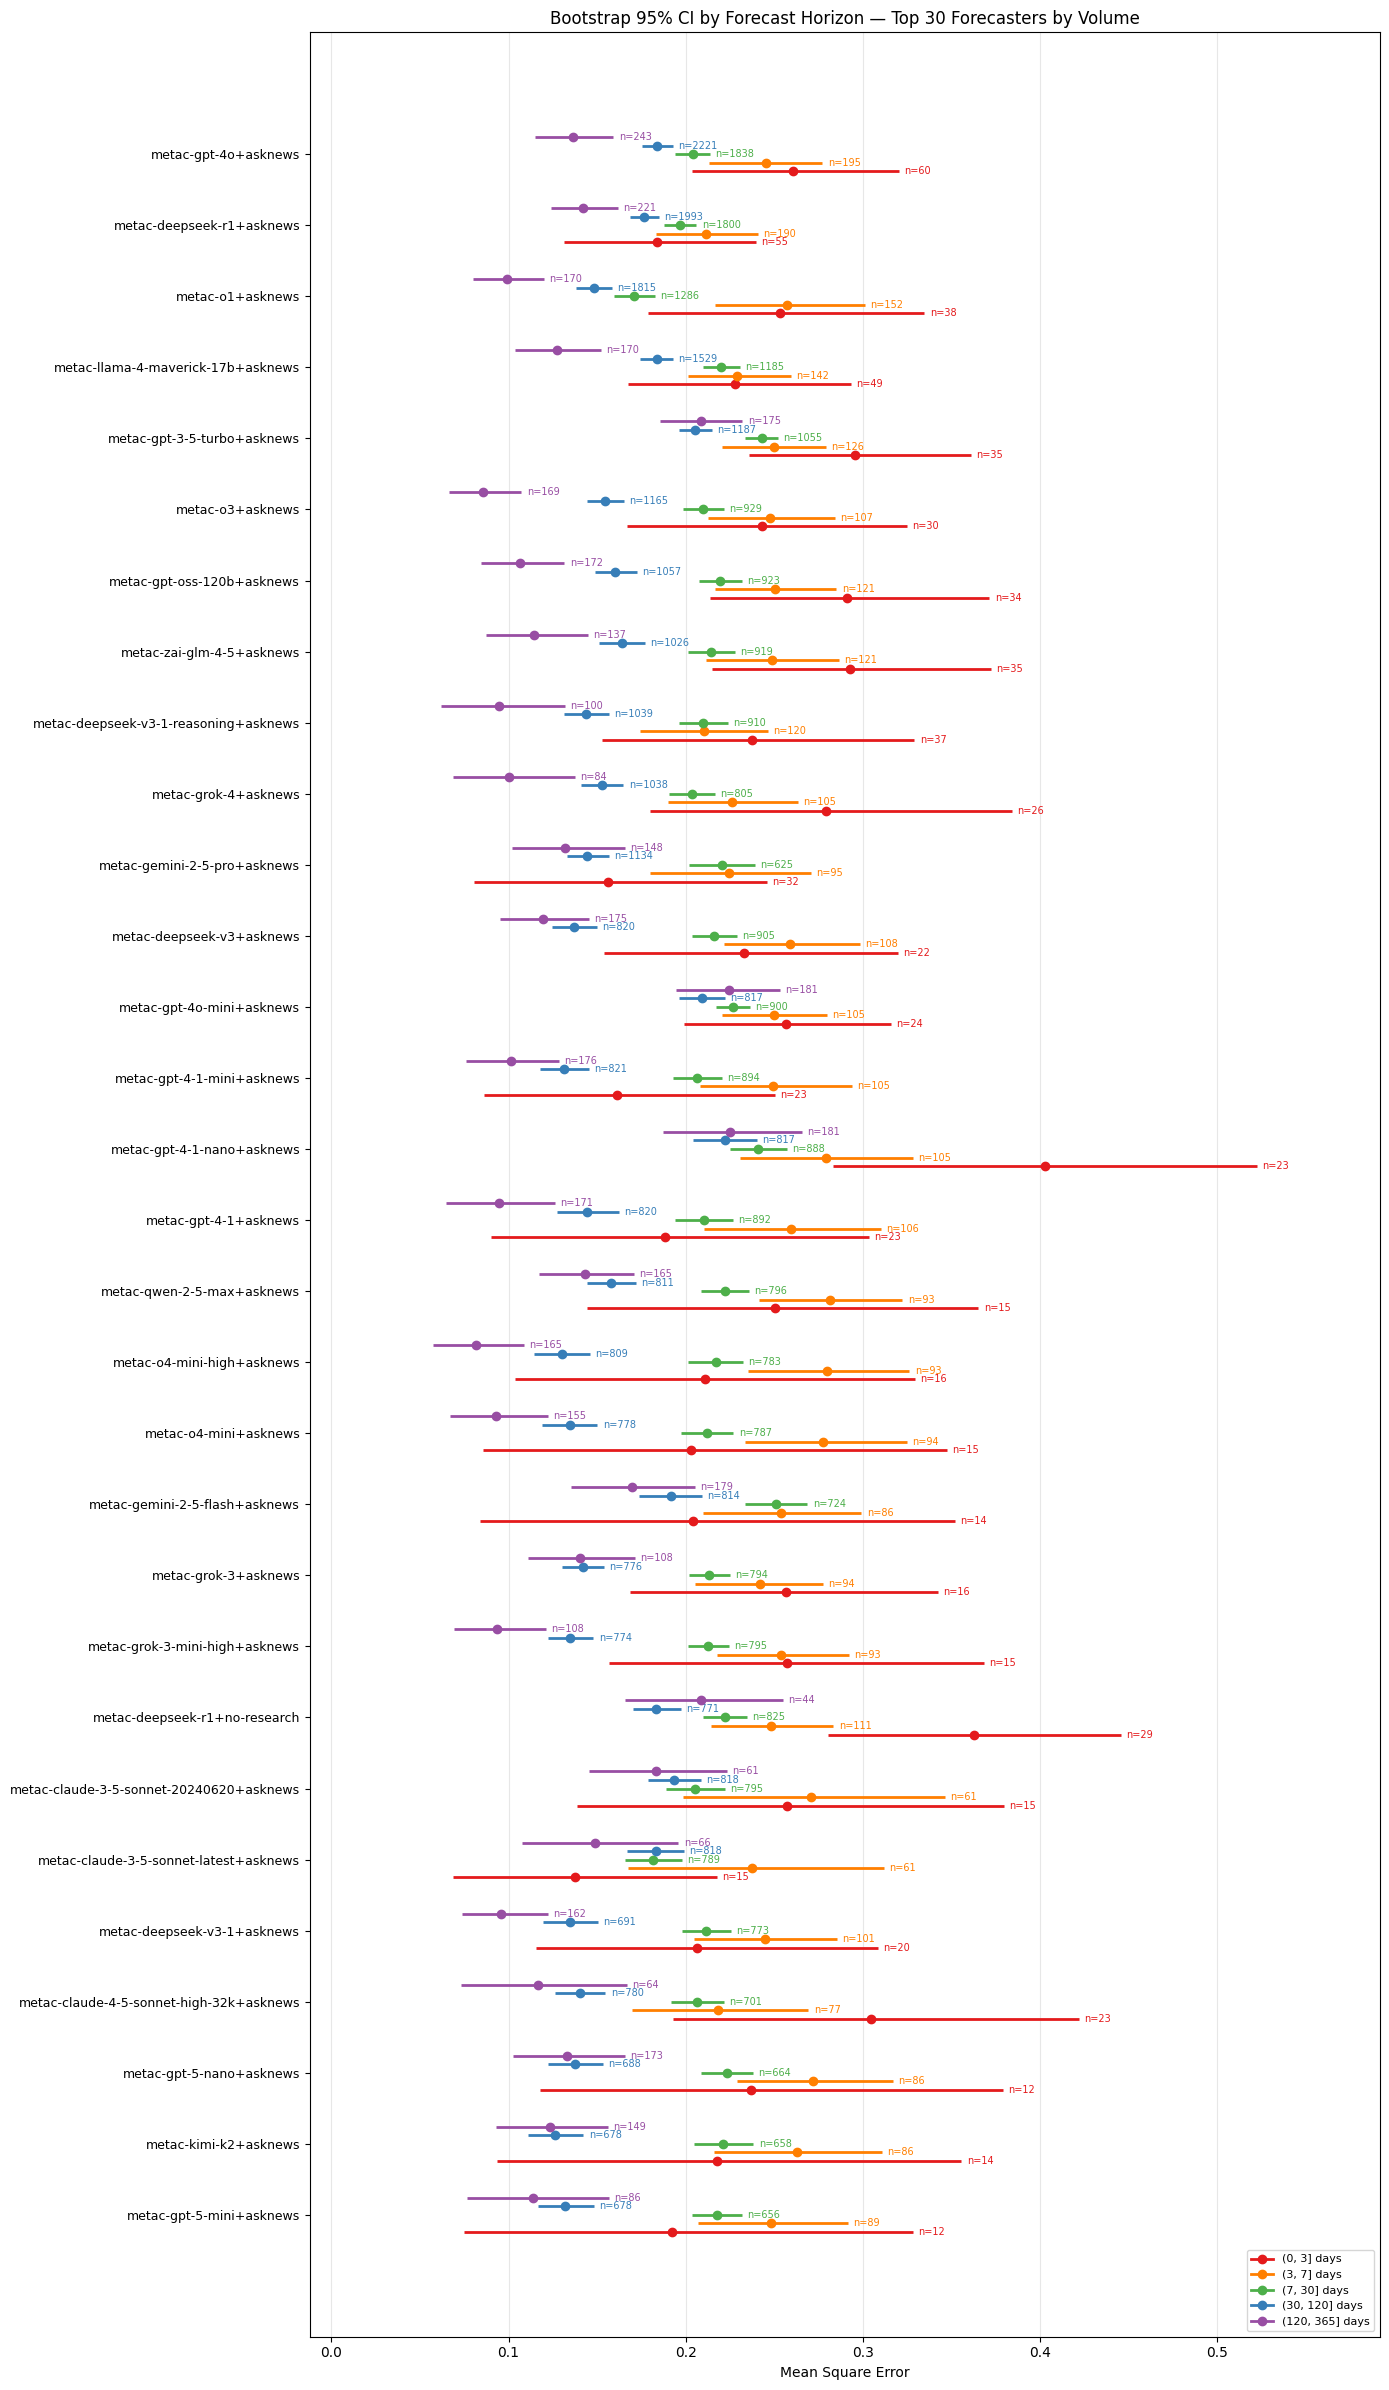

In [10]:
size_cols = [f"bin_{b}_size" for b in bin_maxes]
author_stats["total_forecasts"] = author_stats[size_cols].sum(axis=1)
top30 = author_stats[author_stats["forecaster"] != "metac-uniform-probability-bot"] \
    .nlargest(30, "total_forecasts").reset_index(drop=True)

bin_colors = ["#e41a1c", "#ff7f00", "#4daf4a", "#377eb8", "#984ea3", "#a65628"]
bin_labels = [f"({0 if i == 0 else bin_maxes[i-1]}, {bin_maxes[i]}] days" for i in range(len(bin_maxes))]
n_bins = len(bin_maxes)
n_forecasters = len(top30)
spread = 0.12

fig, ax = plt.subplots(figsize=(14, n_forecasters * 0.8))

for i, (_, row) in enumerate(top30.iterrows()):
    y_base = n_forecasters - 1 - i
    for j, b in enumerate(bin_maxes):
        mse = row[f"bin_{b}_mse"]
        lo = row[f"bin_{b}_ci_lower"]
        hi = row[f"bin_{b}_ci_upper"]
        n = int(row[f"bin_{b}_size"])
        if np.isnan(mse):
            continue
        y = y_base + (j - (n_bins - 1) / 2) * spread
        ax.plot([lo, hi], [y, y], color=bin_colors[j], linewidth=2, solid_capstyle="butt")
        ax.plot(mse, y, "o", color=bin_colors[j], markersize=6, zorder=5)
        ax.text(hi + 0.003, y, f"n={n}", va="center", ha="left", fontsize=7, color=bin_colors[j])

ax.set_yticks(range(n_forecasters))
ax.set_yticklabels(top30["forecaster"].iloc[::-1], fontsize=9)
ax.set_xlabel("Mean Square Error")
ax.set_title("Bootstrap 95% CI by Forecast Horizon — Top 30 Forecasters by Volume")

handles = [plt.Line2D([0], [0], color=c, linewidth=2, marker="o", markersize=6, label=l)
           for c, l in zip(bin_colors, bin_labels)]
ax.legend(handles=handles, loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()


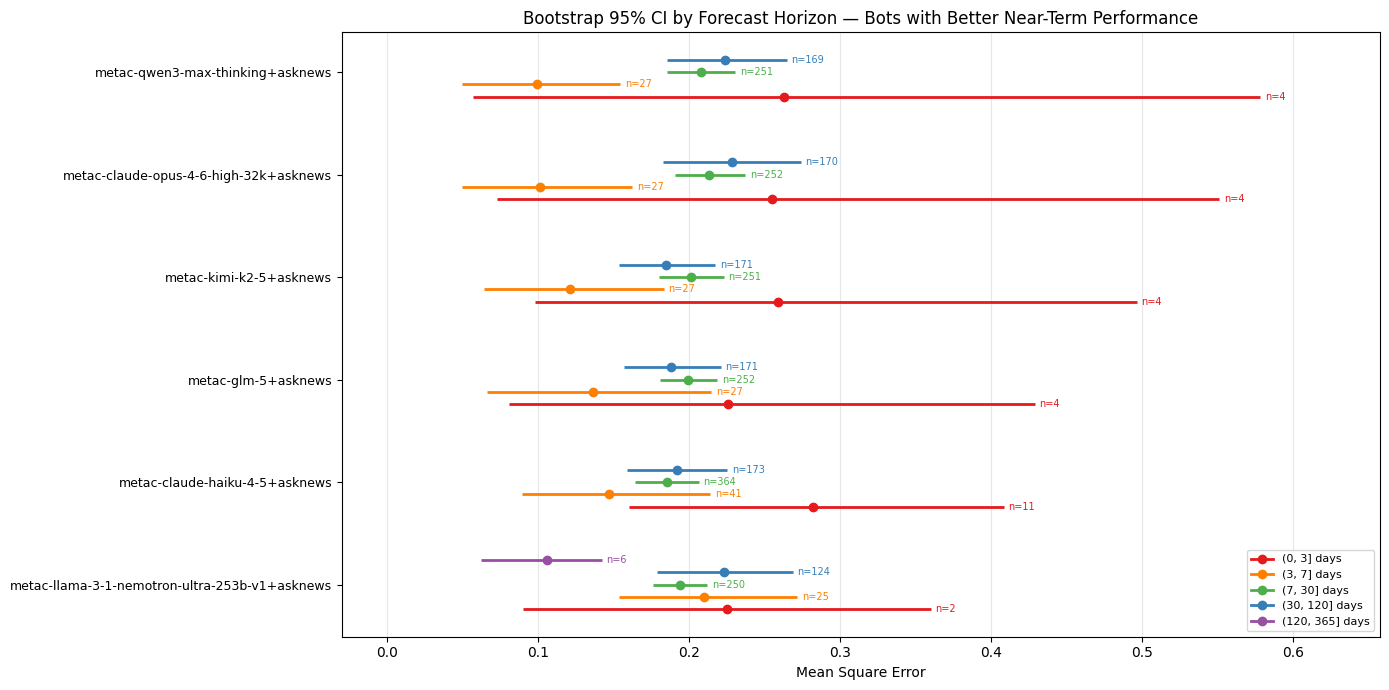

In [11]:
near_better_bots = [
    "metac-qwen3-max-thinking+asknews",
    "metac-claude-opus-4-6-high-32k+asknews",
    "metac-kimi-k2-5+asknews",
    "metac-glm-5+asknews",
    "metac-claude-haiku-4-5+asknews",
    "metac-llama-3-1-nemotron-ultra-253b-v1+asknews",
]
near_better = author_stats[author_stats["forecaster"].isin(near_better_bots)] \
    .set_index("forecaster").loc[near_better_bots].reset_index()

n_forecasters = len(near_better)
n_bins = len(bin_maxes)
spread = 0.12

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(near_better.iterrows()):
    y_base = n_forecasters - 1 - i
    for j, b in enumerate(bin_maxes):
        mse = row[f"bin_{b}_mse"]
        lo = row[f"bin_{b}_ci_lower"]
        hi = row[f"bin_{b}_ci_upper"]
        n = int(row[f"bin_{b}_size"])
        if np.isnan(mse):
            continue
        y = y_base + (j - (n_bins - 1) / 2) * spread
        ax.plot([lo, hi], [y, y], color=bin_colors[j], linewidth=2, solid_capstyle="butt")
        ax.plot(mse, y, "o", color=bin_colors[j], markersize=6, zorder=5)
        ax.text(hi + 0.003, y, f"n={n}", va="center", ha="left", fontsize=7, color=bin_colors[j])

ax.set_yticks(range(n_forecasters))
ax.set_yticklabels(near_better["forecaster"].iloc[::-1], fontsize=9)
ax.set_xlabel("Mean Square Error")
ax.set_title("Bootstrap 95% CI by Forecast Horizon — Bots with Better Near-Term Performance")

handles = [plt.Line2D([0], [0], color=c, linewidth=2, marker="o", markersize=6, label=l)
           for c, l in zip(bin_colors, bin_labels)]
ax.legend(handles=handles, loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## Metaculus Baseline Score Analysis

The Metaculus **baseline score** for binary questions is:

$$\text{score} = \frac{\ln(p_{\text{forecast}} / 0.5)}{\ln(2)} \times 100$$

where $p_{\text{forecast}}$ is the probability assigned to the outcome that actually occurred.

This is a log-scoring rule, **unbounded below** (a confident wrong forecast → $-\infty$). Unlike squared error (bounded [0,1]), extreme outliers can dominate the mean. The bootstrap CIs remain valid but may be wide/asymmetric, especially in small bins where one very wrong confident forecast can pull the mean significantly.

We cannot compute the **peer score** here because it requires other forecasters' predictions on the same question at the same time, which is not available in `binary_reduced`.


In [12]:
from aib_analysis.math.scoring import calculate_baseline_score

_baseline_score = "baseline_score"

binary_baseline = binary[binary[_resolution].isin(["yes", "no"])].copy()
binary_baseline[_baseline_score] = binary_baseline.apply(
    lambda row: calculate_baseline_score(
        forecast=[row[_probability_yes]],
        resolution=True if row[_resolution] == "yes" else False,
        q_type="binary",
    ),
    axis=1,
)

binary_baseline_reduced = binary_baseline[[_forecaster, _baseline_score, _delta_forecast_til_close, 'minibench_type']].copy()
minibench_long = (binary_baseline_reduced["minibench_type"] != "non_minibench") & (binary_baseline_reduced[_delta_forecast_til_close] > 14)
binary_baseline_reduced = binary_baseline_reduced[~minibench_long]

binary_baseline_reduced.describe()

,baseline_score,_delta_forecast_til_close
count,124135.000000,124135.000000
mean,19.904462,40.182604
std,78.207885,40.900980
min,-564.385619,0.010776
25%,-15.200309,10.364834
50%,48.542683,26.495031
75%,76.553475,56.981346
max,98.550043,348.589490


In [13]:
author_stats_baseline = DataFrame()

for author in pd.unique(binary_baseline_reduced[_forecaster]):
    author_forecasts = binary_baseline_reduced[binary_baseline_reduced[_forecaster] == author]
    author_mean = author_forecasts[_baseline_score].mean()

    author_subdf = DataFrame({"forecaster": [author], "mean_baseline": author_mean})

    for i in range(len(bin_maxes)):
        bin_max = bin_maxes[i]
        bin_min = 0 if i == 0 else bin_maxes[i - 1]
        bin_forecasts = author_forecasts[
            (author_forecasts[_delta_forecast_til_close] < bin_max) &
            (author_forecasts[_delta_forecast_til_close] > bin_min)
        ]
        bin_size = bin_forecasts.shape[0]
        bin_mean = bin_forecasts[_baseline_score].mean()
        author_subdf[f"bin_{bin_max}_baseline"] = bin_mean
        author_subdf[f"bin_{bin_max}_size"] = bin_size
    author_stats_baseline = pd.concat([author_stats_baseline, author_subdf])

n_bootstrap = 10_000
ci_level = 0.95
alpha = 1 - ci_level

for i in range(len(bin_maxes)):
    bin_max = bin_maxes[i]
    bin_min = 0 if i == 0 else bin_maxes[i - 1]

    ci_lower_col = f"bin_{bin_max}_ci_lower"
    ci_upper_col = f"bin_{bin_max}_ci_upper"
    author_stats_baseline[ci_lower_col] = np.nan
    author_stats_baseline[ci_upper_col] = np.nan

    for author in author_stats_baseline["forecaster"]:
        author_forecasts = binary_baseline_reduced[binary_baseline_reduced[_forecaster] == author]
        bin_data = author_forecasts.loc[
            (author_forecasts[_delta_forecast_til_close] > bin_min) &
            (author_forecasts[_delta_forecast_til_close] < bin_max),
            _baseline_score
        ].values

        n = len(bin_data)
        if n == 0:
            continue

        bootstrap_means = np.array([
            np.mean(np.random.choice(bin_data, size=n, replace=True))
            for _ in range(n_bootstrap)
        ])

        lower = np.percentile(bootstrap_means, 100 * alpha / 2)
        upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))

        mask = author_stats_baseline["forecaster"] == author
        author_stats_baseline.loc[mask, ci_lower_col] = lower
        author_stats_baseline.loc[mask, ci_upper_col] = upper

author_stats_baseline

,forecaster,mean_baseline,bin_3_baseline,bin_3_size,bin_7_baseline,bin_7_size,bin_30_baseline,bin_30_size,bin_120_baseline,bin_120_size,...,bin_3_ci_lower,bin_3_ci_upper,bin_7_ci_lower,bin_7_ci_upper,bin_30_ci_lower,bin_30_ci_upper,bin_120_ci_lower,bin_120_ci_upper,bin_365_ci_lower,bin_365_ci_upper
0,metac-gpt-4o+asknews,16.540452,-7.493862,60,1.604312,195,12.926386,1828,19.282615,2203,...,-35.717220,15.983185,-9.771714,12.662188,9.277343,16.504707,16.112323,22.411455,31.650800,47.512751
0,metac-o1+asknews,28.644576,-8.702787,38,-9.153032,152,25.422878,1276,33.002989,1797,...,-50.963116,24.584094,-27.185464,8.202039,20.979675,29.723169,29.259613,36.641222,46.259018,60.612683
0,metac-o1-preview,23.864303,-11.566084,12,-9.573609,54,27.162870,660,22.503458,667,...,-49.243956,24.337811,-47.474530,25.311143,19.374711,34.506251,14.740581,29.852623,25.900748,51.986310
0,metac-claude-3-5-sonnet-20240620+asknews,13.505567,-0.618343,15,-10.459277,61,11.395997,795,17.055091,812,...,-39.353147,36.600705,-39.114825,16.332805,4.891753,17.668640,11.682909,22.226951,8.243256,33.381405
0,metac-claude-3-5-sonnet-latest+asknews,20.938722,37.396478,15,4.278193,61,21.132936,789,20.879987,812,...,11.654797,59.624892,-21.221058,29.307415,15.064148,26.906781,15.134730,26.494093,14.950635,44.980180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,metac-o3-mini,2.829176,2.829176,2,NaN,0,NaN,0,NaN,0,...,-32.192809,37.851162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,metac-sonnet-4-search[research-only-bot],55.670506,52.606881,1,NaN,0,57.202318,2,NaN,0,...,52.606881,52.606881,NaN,NaN,37.851162,76.553475,NaN,NaN,NaN,NaN
0,metac-deepseek-r1+sonnet-4-search,57.879613,48.542683,1,NaN,0,62.548079,2,NaN,0,...,48.542683,48.542683,NaN,NaN,48.542683,76.553475,NaN,NaN,NaN,NaN
0,metac-gpt-5-search[research-only-bot],34.922599,60.407132,1,NaN,0,22.180333,2,NaN,0,...,60.407132,60.407132,NaN,NaN,-32.192809,76.553475,NaN,NaN,NaN,NaN


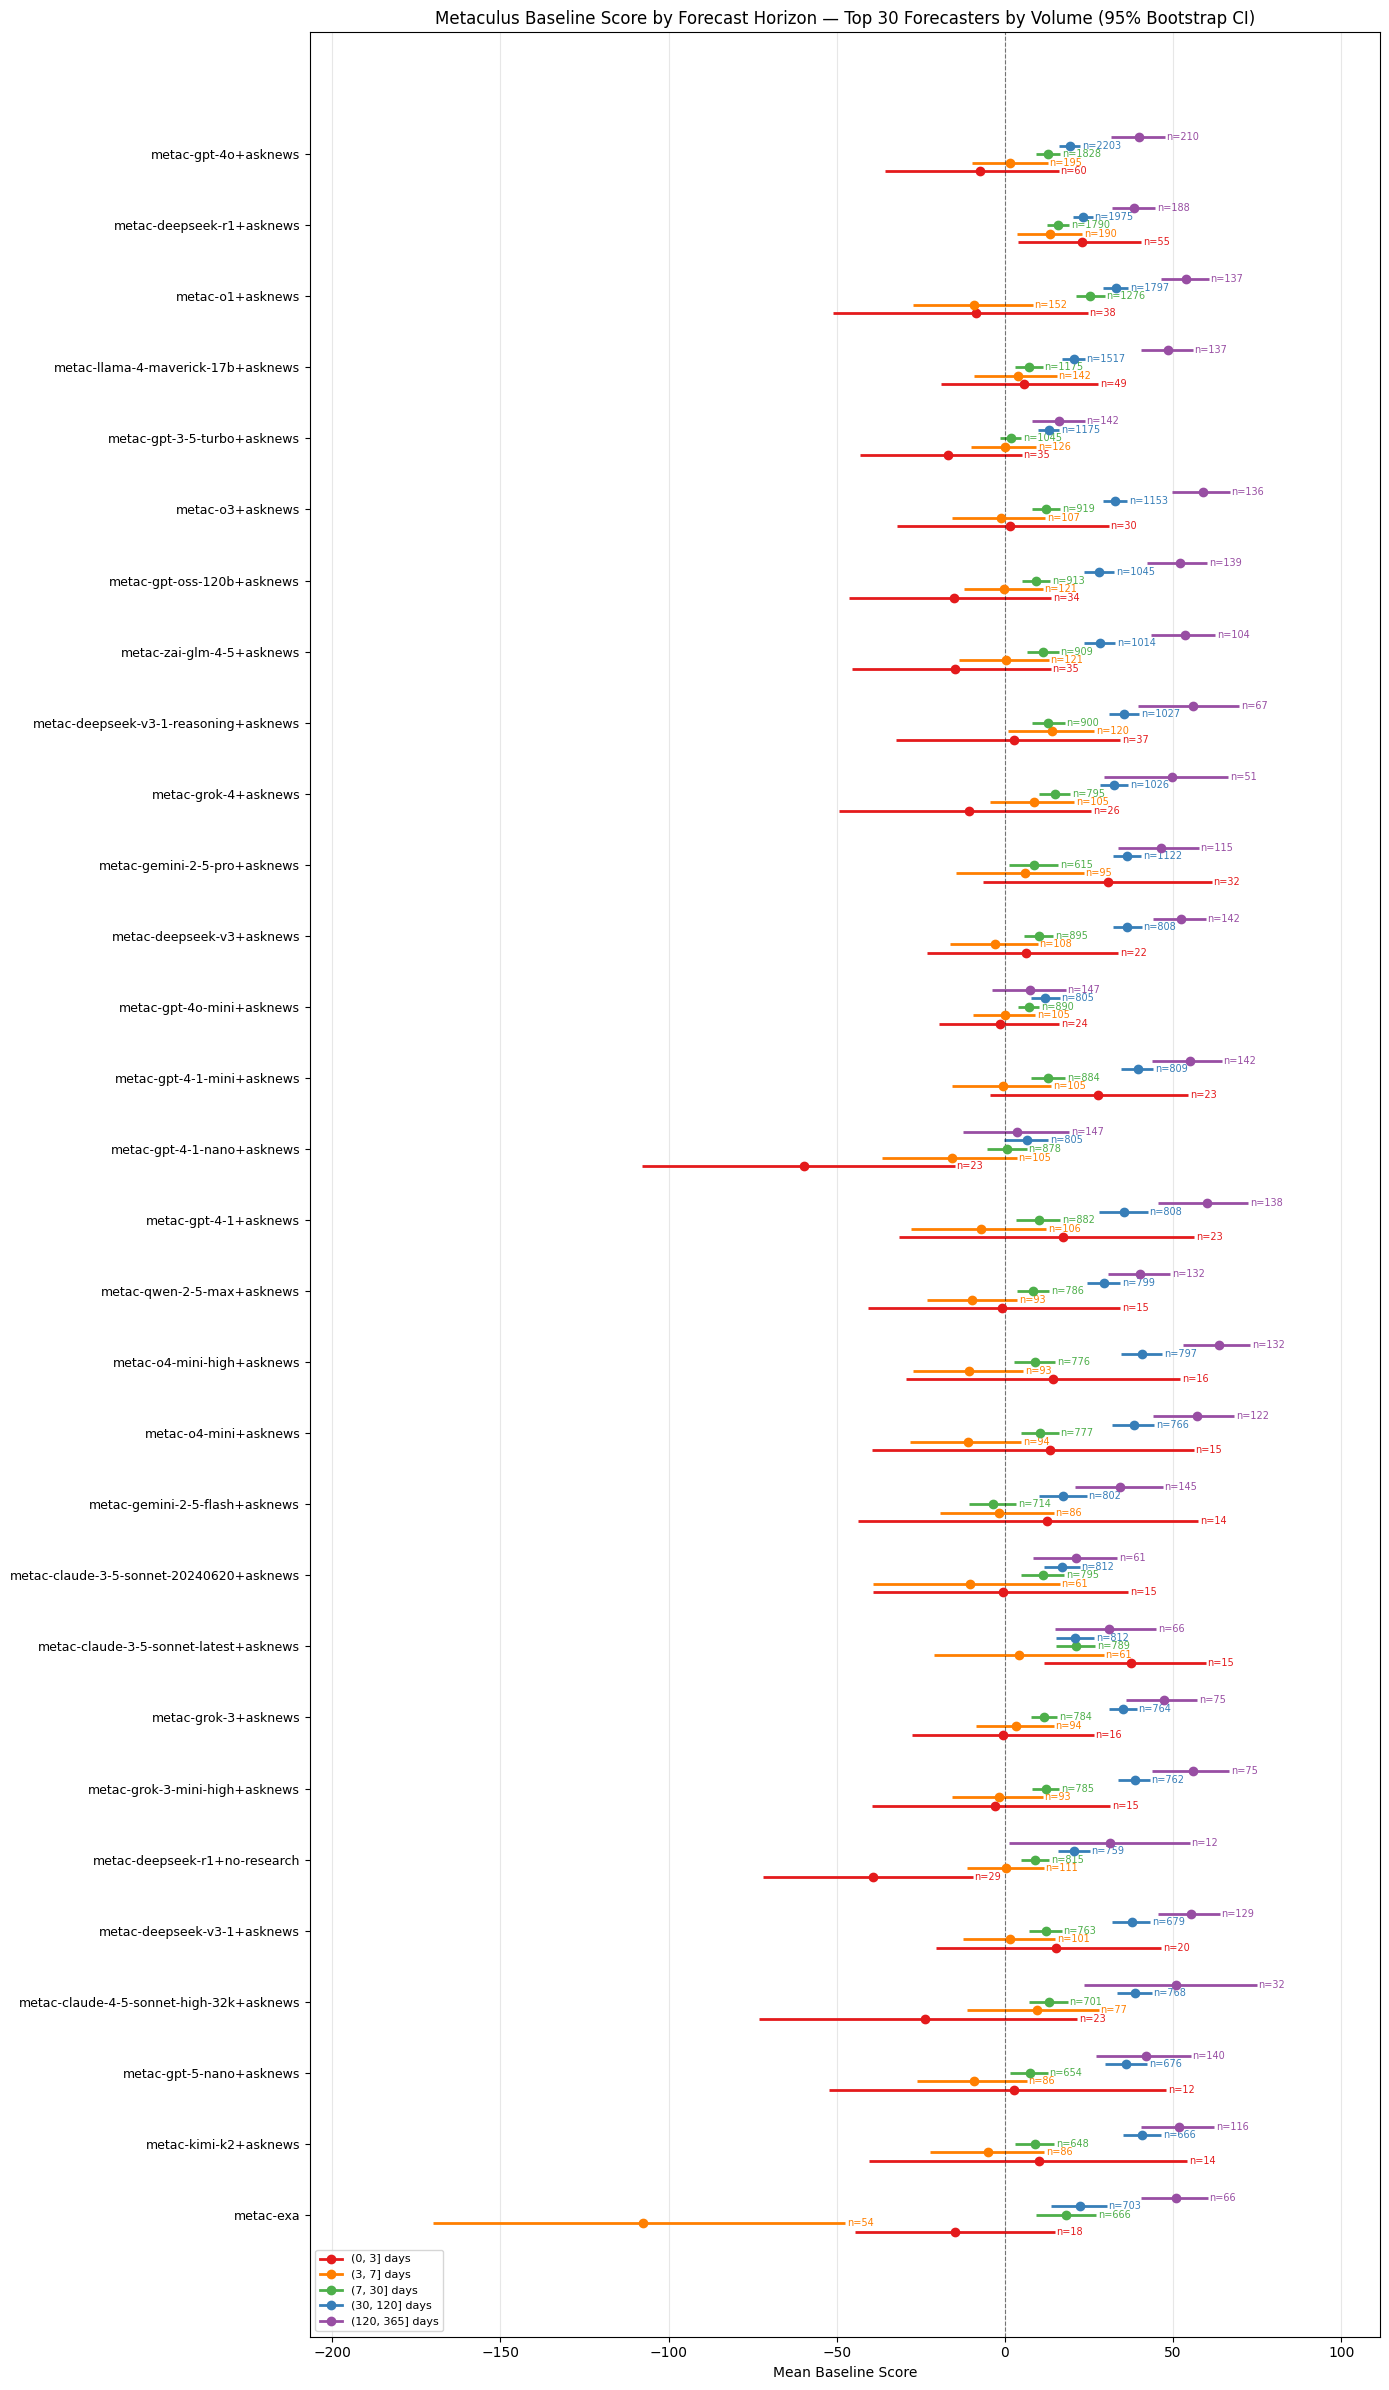

In [14]:
size_cols_b = [f"bin_{b}_size" for b in bin_maxes]
author_stats_baseline["total_forecasts"] = author_stats_baseline[size_cols_b].sum(axis=1)
top30_baseline = author_stats_baseline[
    author_stats_baseline["forecaster"] != "metac-uniform-probability-bot"
].nlargest(30, "total_forecasts").reset_index(drop=True)

bin_colors = ["#e41a1c", "#ff7f00", "#4daf4a", "#377eb8", "#984ea3", "#a65628"]
bin_labels = [f"({0 if i == 0 else bin_maxes[i-1]}, {bin_maxes[i]}] days" for i in range(len(bin_maxes))]
n_bins = len(bin_maxes)
n_forecasters = len(top30_baseline)
spread = 0.12

fig, ax = plt.subplots(figsize=(14, n_forecasters * 0.8))

for i, (_, row) in enumerate(top30_baseline.iterrows()):
    y_base = n_forecasters - 1 - i
    for j, b in enumerate(bin_maxes):
        mse = row[f"bin_{b}_baseline"]
        lo = row[f"bin_{b}_ci_lower"]
        hi = row[f"bin_{b}_ci_upper"]
        n = int(row[f"bin_{b}_size"])
        if np.isnan(mse):
            continue
        y = y_base + (j - (n_bins - 1) / 2) * spread
        ax.plot([lo, hi], [y, y], color=bin_colors[j], linewidth=2, solid_capstyle="butt")
        ax.plot(mse, y, "o", color=bin_colors[j], markersize=6, zorder=5)
        ax.text(hi + 0.5, y, f"n={n}", va="center", ha="left", fontsize=7, color=bin_colors[j])

ax.set_yticks(range(n_forecasters))
ax.set_yticklabels(top30_baseline["forecaster"].iloc[::-1], fontsize=9)
ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Mean Baseline Score")
ax.set_title("Metaculus Baseline Score by Forecast Horizon — Top 30 Forecasters by Volume (95% Bootstrap CI)")

handles = [plt.Line2D([0], [0], color=c, linewidth=2, marker="o", markersize=6, label=l)
           for c, l in zip(bin_colors, bin_labels)]
ax.legend(handles=handles, loc="lower left", fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()


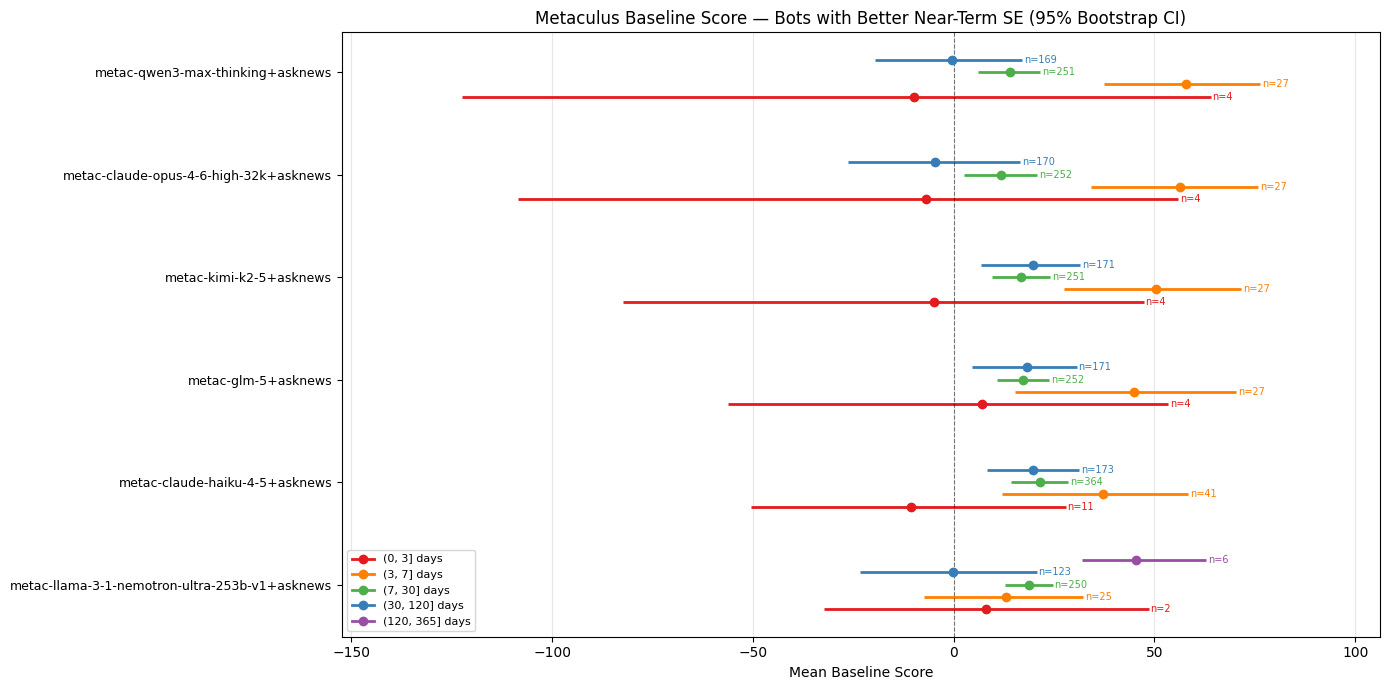

In [15]:
near_better_baseline = author_stats_baseline[
    author_stats_baseline["forecaster"].isin(near_better_bots)
].set_index("forecaster").loc[near_better_bots].reset_index()

n_forecasters = len(near_better_baseline)
n_bins = len(bin_maxes)
spread = 0.12

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(near_better_baseline.iterrows()):
    y_base = n_forecasters - 1 - i
    for j, b in enumerate(bin_maxes):
        score = row[f"bin_{b}_baseline"]
        lo = row[f"bin_{b}_ci_lower"]
        hi = row[f"bin_{b}_ci_upper"]
        n = int(row[f"bin_{b}_size"])
        if np.isnan(score):
            continue
        y = y_base + (j - (n_bins - 1) / 2) * spread
        ax.plot([lo, hi], [y, y], color=bin_colors[j], linewidth=2, solid_capstyle="butt")
        ax.plot(score, y, "o", color=bin_colors[j], markersize=6, zorder=5)
        ax.text(hi + 0.5, y, f"n={n}", va="center", ha="left", fontsize=7, color=bin_colors[j])

ax.set_yticks(range(n_forecasters))
ax.set_yticklabels(near_better_baseline["forecaster"].iloc[::-1], fontsize=9)
ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Mean Baseline Score")
ax.set_title("Metaculus Baseline Score — Bots with Better Near-Term SE (95% Bootstrap CI)")

handles = [plt.Line2D([0], [0], color=c, linewidth=2, marker="o", markersize=6, label=l)
           for c, l in zip(bin_colors, bin_labels)]
ax.legend(handles=handles, loc="lower left", fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

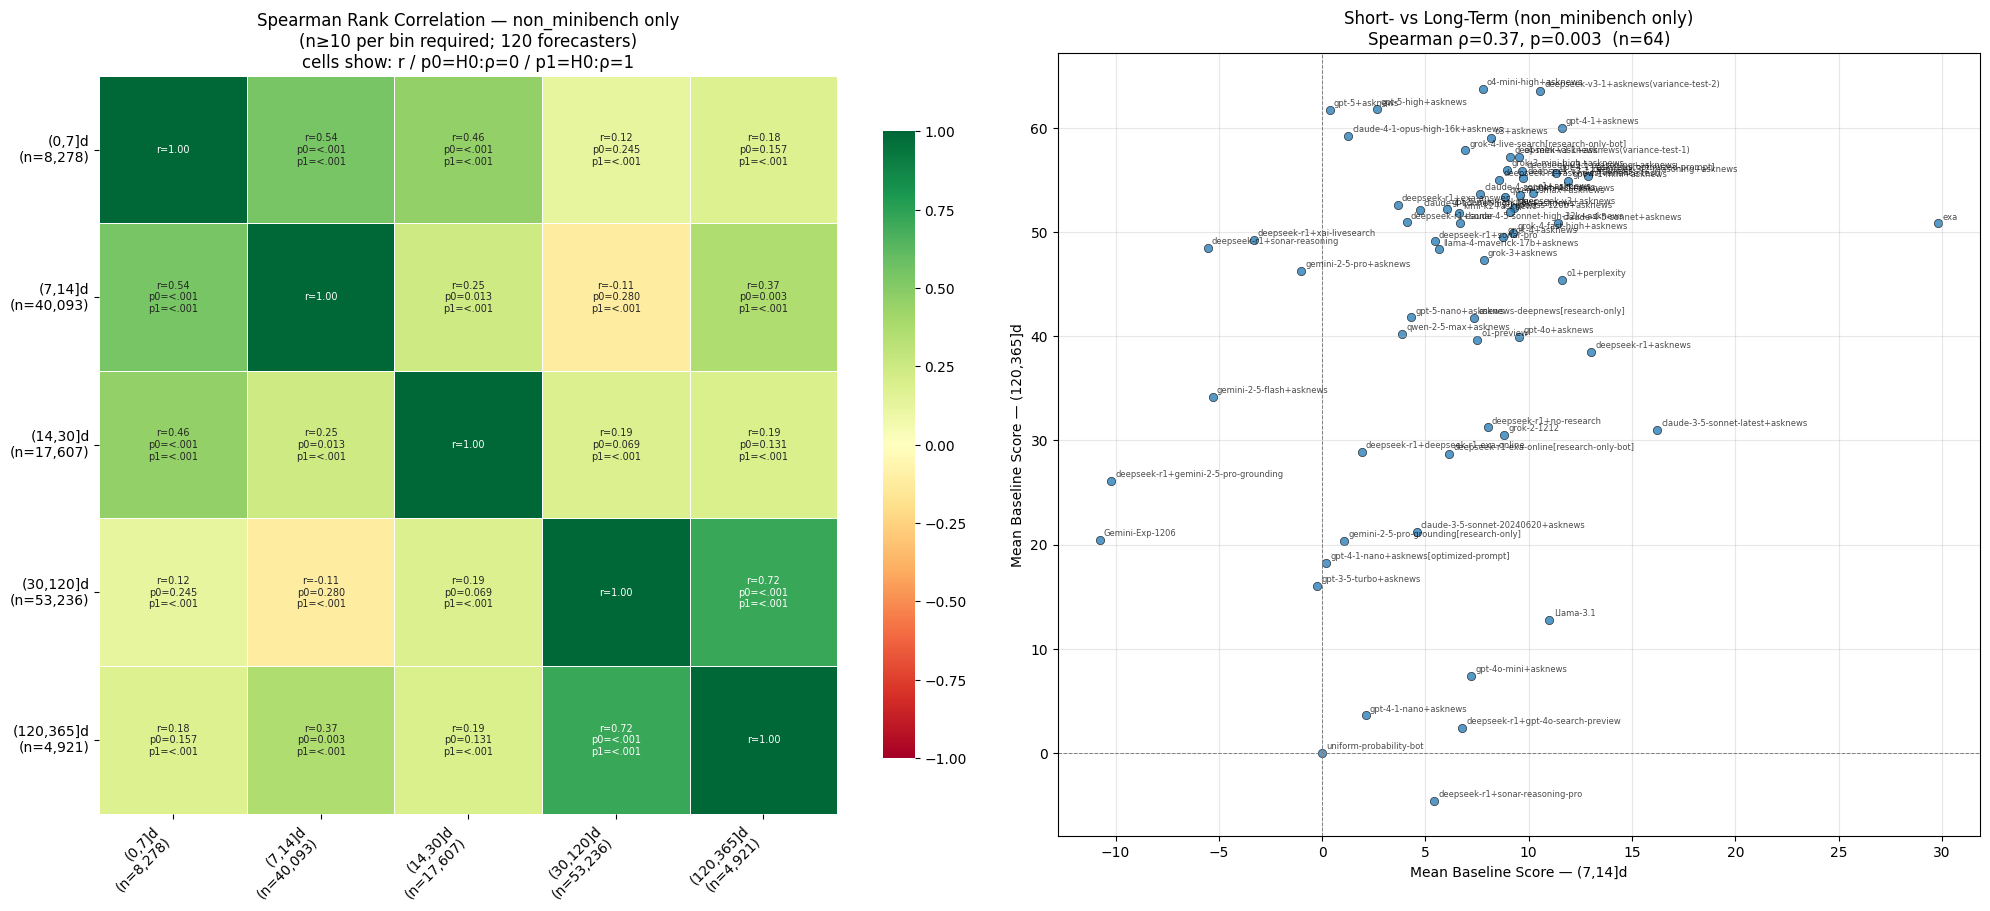


Pairwise Spearman correlations — non_minibench only:
Pair                                          r     p0(ρ=0)     p1(ρ=1)      n
--------------------------------------------------------------------------------
(0,7]d vs (7,14]d                      0.540       <.001       <.001    114
(0,7]d vs (14,30]d                     0.459       <.001       <.001     91
(0,7]d vs (30,120]d                    0.123       0.245       <.001     91
(0,7]d vs (120,365]d                   0.179       0.157       <.001     64
(7,14]d vs (14,30]d                     0.250       0.013       <.001     97
(7,14]d vs (30,120]d                   -0.111       0.280       <.001     97
(7,14]d vs (120,365]d                   0.366       0.003       <.001     64
(14,30]d vs (30,120]d                    0.186       0.069       <.001     97
(14,30]d vs (120,365]d                   0.191       0.131       <.001     64
(30,120]d vs (120,365]d                   0.716       <.001       <.001     64


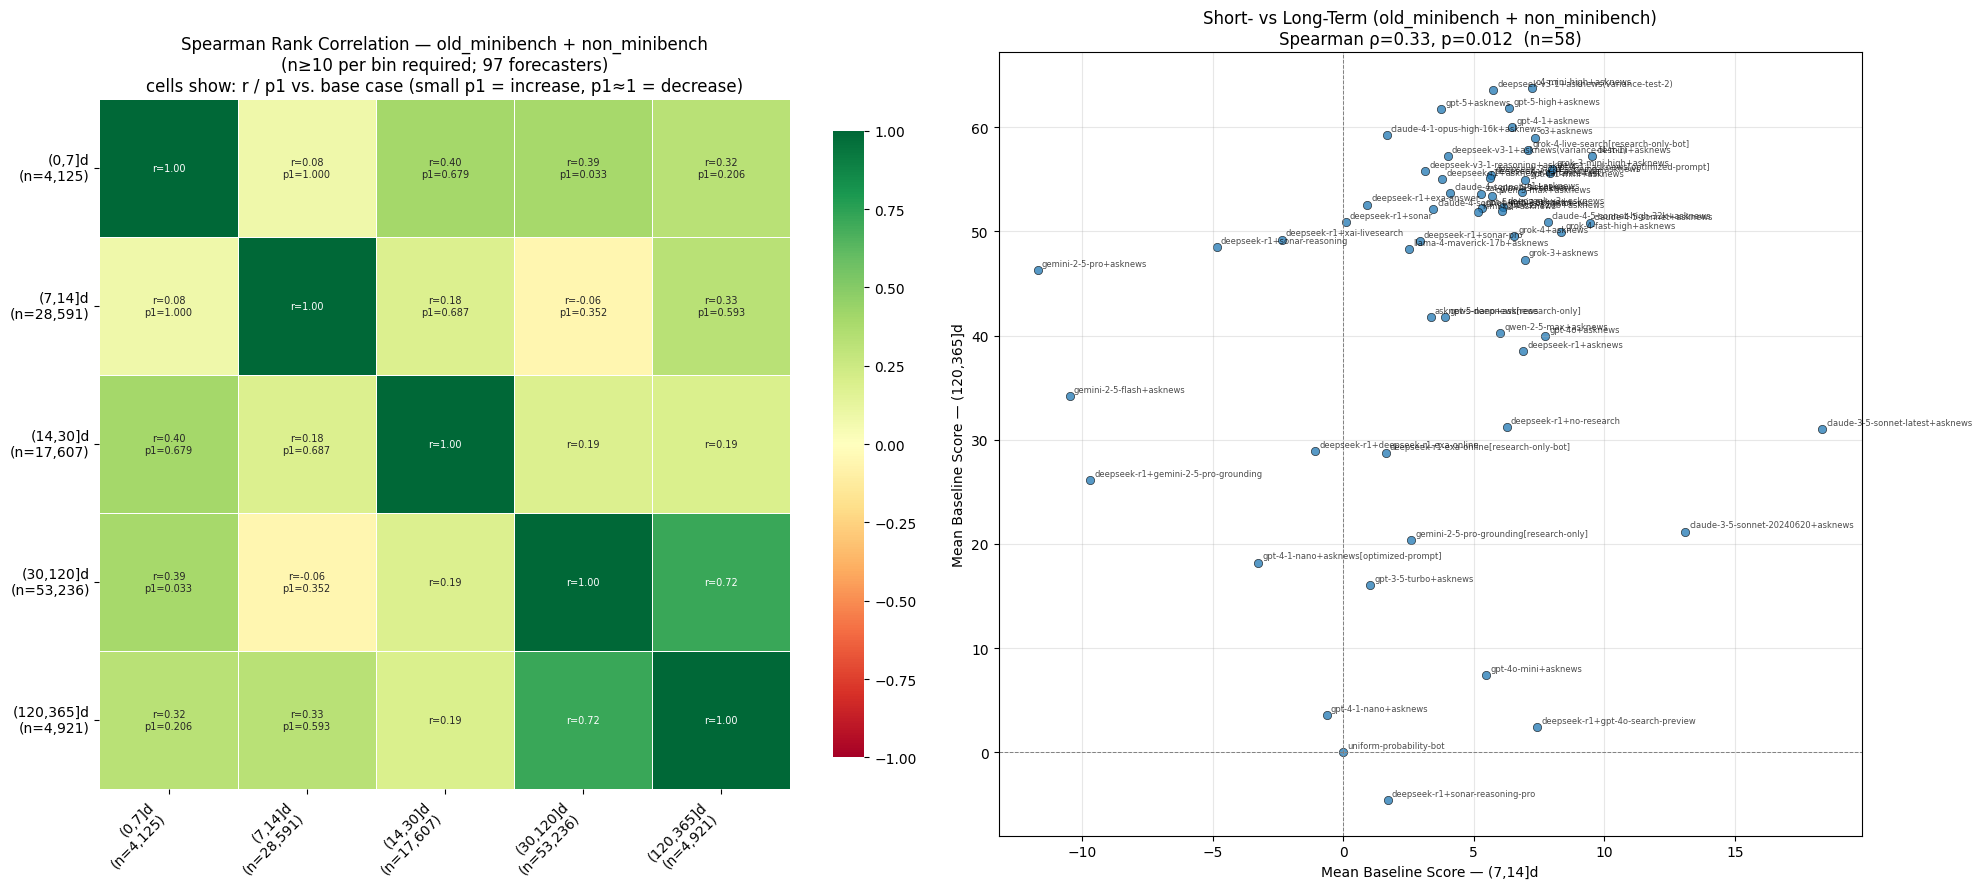


Pairwise Spearman correlations — old_minibench + non_minibench:
Pair                                          r          p1      n
--------------------------------------------------------------------------------
(0,7]d vs (7,14]d                      0.085       1.000     77
(0,7]d vs (14,30]d                     0.399       0.679     77
(0,7]d vs (30,120]d                    0.392       0.033     77
(0,7]d vs (120,365]d                   0.323       0.206     56
(7,14]d vs (14,30]d                     0.181       0.687     91
(7,14]d vs (30,120]d                   -0.055       0.352     91
(7,14]d vs (120,365]d                   0.328       0.593     58
(14,30]d vs (30,120]d                    0.186       0.500     97
(14,30]d vs (120,365]d                   0.191       0.500     64
(30,120]d vs (120,365]d                   0.716       0.500     64


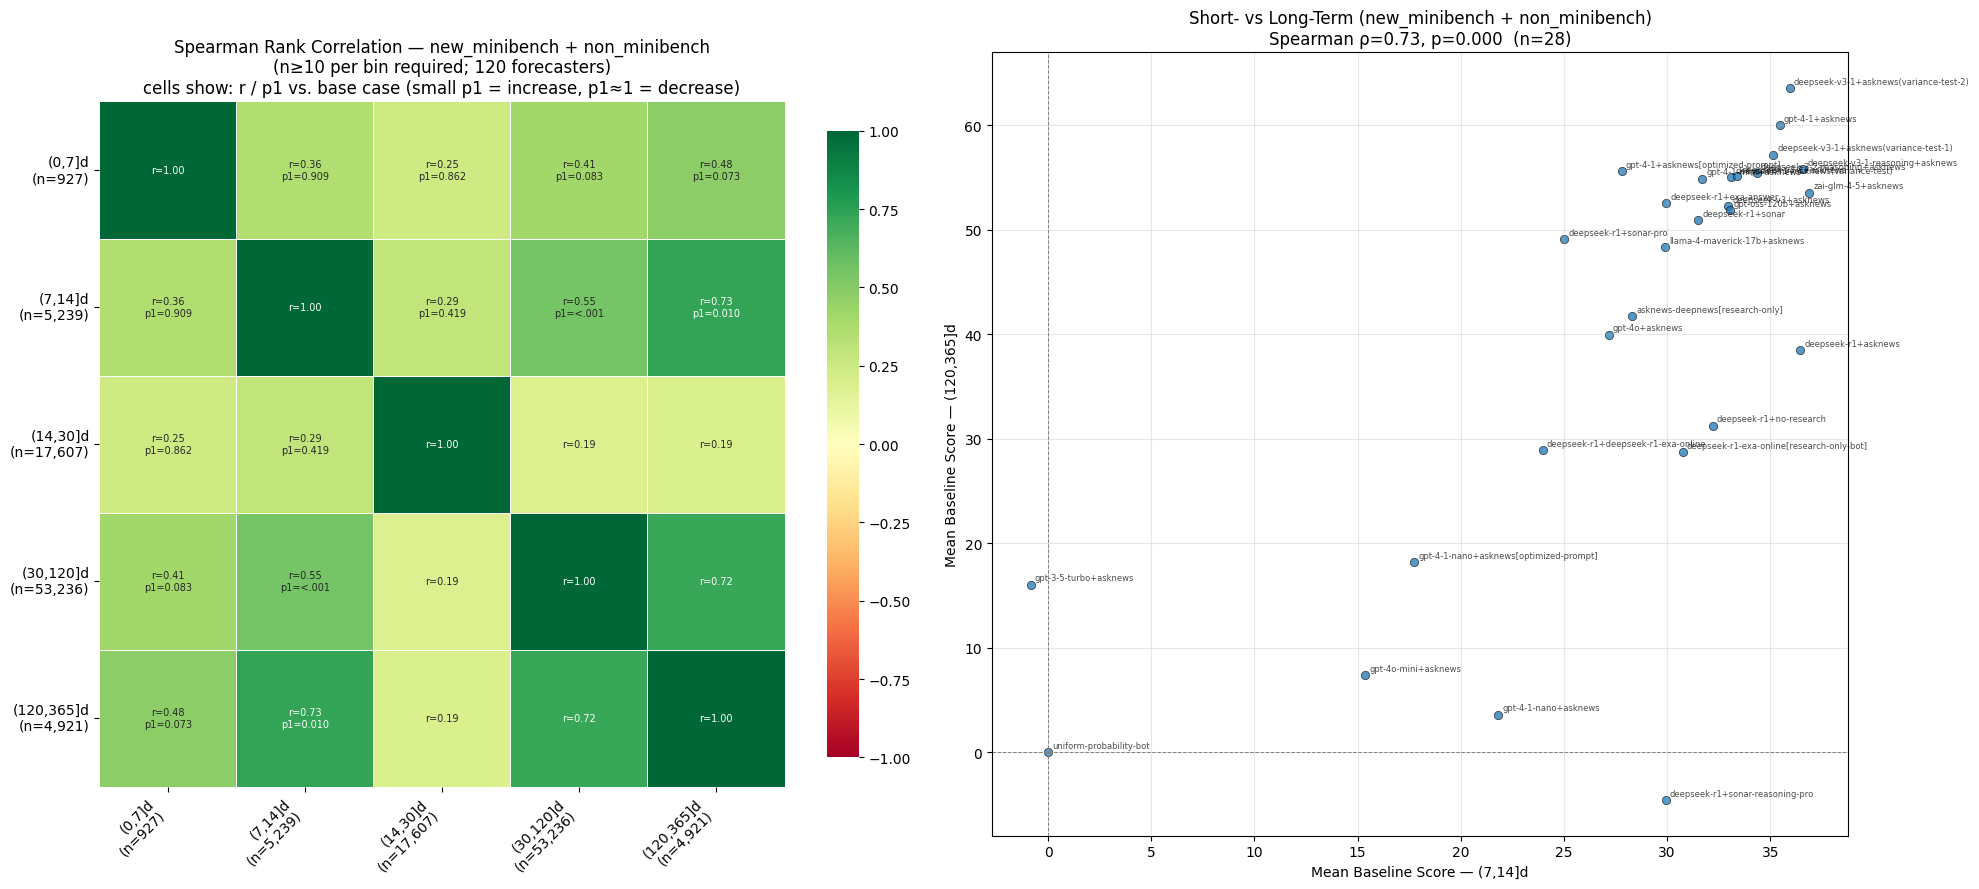


Pairwise Spearman correlations — new_minibench + non_minibench:
Pair                                          r          p1      n
--------------------------------------------------------------------------------
(0,7]d vs (7,14]d                      0.359       0.909     52
(0,7]d vs (14,30]d                     0.248       0.862     29
(0,7]d vs (30,120]d                    0.408       0.083     29
(0,7]d vs (120,365]d                   0.482       0.073     28
(7,14]d vs (14,30]d                     0.292       0.419     29
(7,14]d vs (30,120]d                    0.550       <.001     29
(7,14]d vs (120,365]d                   0.733       0.010     28
(14,30]d vs (30,120]d                    0.186       0.500     97
(14,30]d vs (120,365]d                   0.191       0.500     64
(30,120]d vs (120,365]d                   0.716       0.500     64


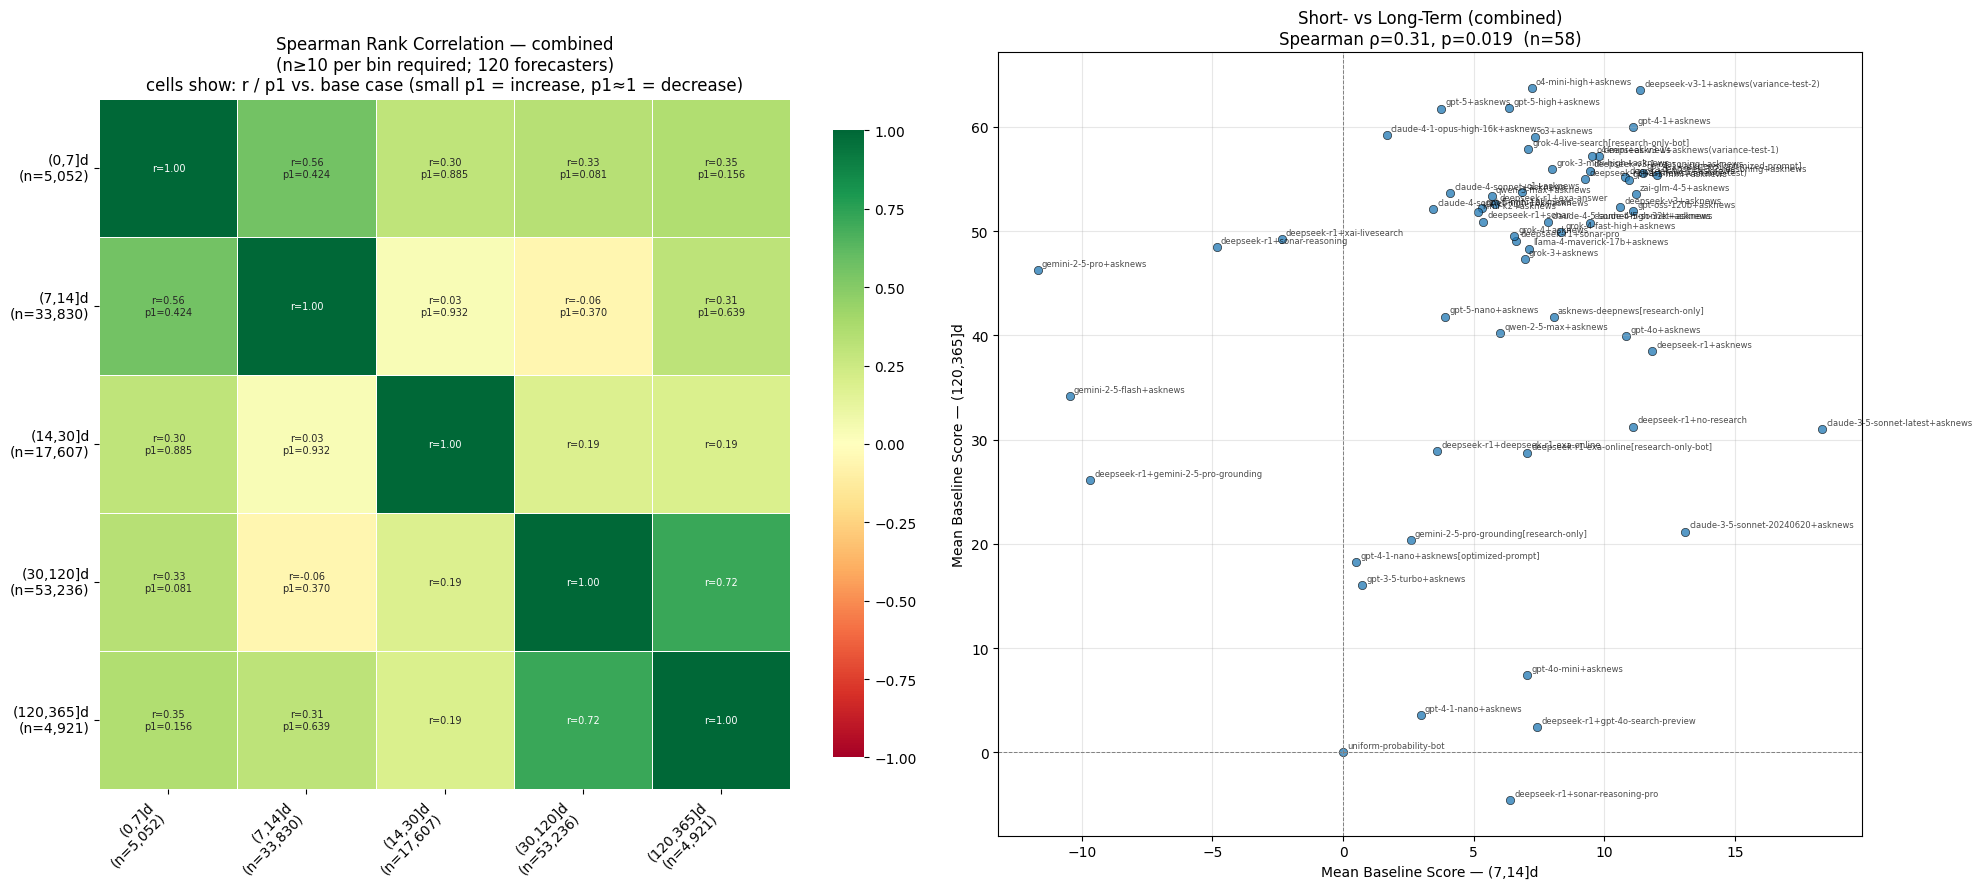


Pairwise Spearman correlations — combined:
Pair                                          r          p1      n
--------------------------------------------------------------------------------
(0,7]d vs (7,14]d                      0.559       0.424    100
(0,7]d vs (14,30]d                     0.297       0.885     77
(0,7]d vs (30,120]d                    0.331       0.081     77
(0,7]d vs (120,365]d                   0.355       0.156     56
(7,14]d vs (14,30]d                     0.034       0.932     91
(7,14]d vs (30,120]d                   -0.062       0.370     91
(7,14]d vs (120,365]d                   0.307       0.639     58
(14,30]d vs (30,120]d                    0.186       0.500     97
(14,30]d vs (120,365]d                   0.191       0.500     64
(30,120]d vs (120,365]d                   0.716       0.500     64


In [24]:
import seaborn as sns
from scipy import stats

min_n_per_bin = 10
corr_bin_maxes = [7, 14, 30, 120, 365]
corr_bin_labels = [f"({0 if i == 0 else corr_bin_maxes[i-1]},{corr_bin_maxes[i]}]d" for i in range(len(corr_bin_maxes))]
MB_CUTOFF = 14
BASE_LABEL = "non_minibench only"

def pval_vs_rho(r, n, rho_0):
    """Two-tailed p-value for H0: rho = rho_0 via Fisher z-transformation."""
    if n < 4 or np.isnan(r):
        return np.nan
    r_c    = np.clip(r,     -0.9999, 0.9999)
    rho_c  = np.clip(rho_0, -0.9999, 0.9999)
    z = (np.arctanh(r_c) - np.arctanh(rho_c)) * np.sqrt(n - 3)
    return float(2 * (1 - stats.norm.cdf(abs(z))))

def pval_vs_base(r1, n1, r0, n0):
    """One-tailed p-value for H1: phi_1 > phi_0, comparing an independent Spearman
    correlation (phi_1) against the base-case correlation (phi_0) via the two-sample
    Fisher z-transformation test. Since this is complementary to H1: phi_1 < phi_0
    (the two always sum to 1), this single value is enough to read off either
    direction: small p1 => evidence of an increase, p1 near 1 => evidence of a decrease."""
    if n1 < 4 or n0 < 4 or np.isnan(r1) or np.isnan(r0):
        return np.nan
    r1_c = np.clip(r1, -0.9999, 0.9999)
    r0_c = np.clip(r0, -0.9999, 0.9999)
    se = np.sqrt(1 / (n1 - 3) + 1 / (n0 - 3))
    z = (np.arctanh(r1_c) - np.arctanh(r0_c)) / se
    return float(1 - stats.norm.cdf(z))

def fmt_p(p):
    if np.isnan(p): return "N/A"
    if p < 0.001:   return "<.001"
    return f"{p:.3f}"

def build_score_df(data, mb_types_for_short=None):
    score_matrix = {}
    annot_labels = []
    for i, b in enumerate(corr_bin_maxes):
        bin_min = 0 if i == 0 else corr_bin_maxes[i - 1]
        bin_data = data[(data[_delta_forecast_til_close] > bin_min) & (data[_delta_forecast_til_close] < b)]
        if mb_types_for_short is not None:
            if b <= MB_CUTOFF:
                bin_data = bin_data[bin_data["minibench_type"].isin(mb_types_for_short)]
            else:
                bin_data = bin_data[bin_data["minibench_type"] == "non_minibench"]
        counts = bin_data.groupby(_forecaster)[_baseline_score].count()
        means  = bin_data.groupby(_forecaster)[_baseline_score].mean()
        col = {f: (means[f] if counts.get(f, 0) >= min_n_per_bin else np.nan) for f in means.index}
        score_matrix[corr_bin_labels[i]] = col
        annot_labels.append(f"{corr_bin_labels[i]}\n(n={len(bin_data):,})")
    df = pd.DataFrame(score_matrix)[corr_bin_labels]
    df = df[df.notna().sum(axis=1) >= 2]
    return df, annot_labels

LONG_TERM_LABELS = {corr_bin_labels[i] for i, b in enumerate(corr_bin_maxes) if b > MB_CUTOFF}

def make_annot_matrix(score_df, corr, base_score_df=None, base_corr=None):
    cols = corr.columns
    mat = np.empty(corr.shape, dtype=object)
    for i, ca in enumerate(cols):
        for j, cb in enumerate(cols):
            r = corr.loc[ca, cb]
            n = int(score_df[[ca, cb]].dropna().shape[0])
            if np.isnan(r):
                mat[i, j] = ""
                continue
            if ca == cb:
                # Diagonal is always phi=1 by construction; a p-value is meaningless here.
                mat[i, j] = f"r={r:.2f}"
            elif base_corr is None:
                p0 = pval_vs_rho(r, n, 0)
                p1 = pval_vs_rho(r, n, 1)
                mat[i, j] = f"r={r:.2f}\np0={fmt_p(p0)}\np1={fmt_p(p1)}"
            elif ca in LONG_TERM_LABELS and cb in LONG_TERM_LABELS:
                # These bins are always filtered to non_minibench data, identical
                # to the base case, so the comparison p-values are redundant.
                mat[i, j] = f"r={r:.2f}"
            else:
                if ca in base_corr.index and cb in base_corr.columns:
                    r0 = base_corr.loc[ca, cb]
                    n0 = int(base_score_df[[ca, cb]].dropna().shape[0])
                else:
                    r0, n0 = np.nan, 0
                p1 = pval_vs_base(r, n, r0, n0)
                mat[i, j] = f"r={r:.2f}\np1={fmt_p(p1)}"
    return mat

charts = [
    (BASE_LABEL,                       binary_baseline_reduced, None),
    ("old_minibench + non_minibench", binary_baseline_reduced, ["old_minibench"]),
    ("new_minibench + non_minibench", binary_baseline_reduced, ["new_minibench"]),
    ("combined",                      binary_baseline_reduced, ["old_minibench", "new_minibench"]),
]

base_score_df, base_corr = None, None

for label, data, mb_types in charts:
    is_base = (label == BASE_LABEL)
    score_df, annot_labels = build_score_df(data, mb_types)
    spearman_corr = score_df.corr(method="spearman")
    if is_base:
        annot_mat = make_annot_matrix(score_df, spearman_corr)
        base_score_df, base_corr = score_df, spearman_corr
    else:
        annot_mat = make_annot_matrix(score_df, spearman_corr, base_score_df, base_corr)

    n_bins = len(corr_bin_labels)
    fig, axes = plt.subplots(1, 2, figsize=(20, max(9, n_bins * 1.6)))

    sns.heatmap(
        spearman_corr,
        ax=axes[0],
        annot=annot_mat,
        fmt="",
        cmap="RdYlGn",
        vmin=-1, vmax=1,
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 7},
    )
    p_desc = (
        "cells show: r / p0=H0:ρ=0 / p1=H0:ρ=1" if is_base
        else "cells show: r / p1 vs. base case (small p1 = increase, p1≈1 = decrease)"
    )
    axes[0].set_title(
        f"Spearman Rank Correlation — {label}\n"
        f"(n≥{min_n_per_bin} per bin required; {len(score_df)} forecasters)\n"
        f"{p_desc}"
    )
    axes[0].set_xticklabels(annot_labels, rotation=45, ha="right")
    axes[0].set_yticklabels(annot_labels, rotation=0)

    short_col = corr_bin_labels[1]
    long_col  = corr_bin_labels[-1]
    valid = score_df[[short_col, long_col]].dropna() if short_col in score_df.columns and long_col in score_df.columns else pd.DataFrame()
    if len(valid) >= 3:
        rho, pval = stats.spearmanr(valid[short_col], valid[long_col])
        axes[1].scatter(valid[short_col], valid[long_col], alpha=0.75, edgecolors="k", linewidths=0.5)
        for forecaster, row in valid.iterrows():
            axes[1].annotate(
                forecaster.replace("metac-", ""),
                (row[short_col], row[long_col]),
                fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords="offset points",
            )
        axes[1].axvline(0, color="gray", linewidth=0.7, linestyle="--")
        axes[1].axhline(0, color="gray", linewidth=0.7, linestyle="--")
        axes[1].set_xlabel(f"Mean Baseline Score — {short_col}")
        axes[1].set_ylabel(f"Mean Baseline Score — {long_col}")
        axes[1].set_title(f"Short- vs Long-Term ({label})\nSpearman ρ={rho:.2f}, p={pval:.3f}  (n={len(valid)})")
    else:
        axes[1].text(0.5, 0.5, f"Insufficient data\n(n={len(valid)})", ha="center", va="center",
                     transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title(f"Short- vs Long-Term ({label})")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nPairwise Spearman correlations — {label}:")
    if is_base:
        print(f"{'Pair':<40} {'r':>6}  {'p0(ρ=0)':>10}  {'p1(ρ=1)':>10}  {'n':>5}")
    else:
        print(f"{'Pair':<40} {'r':>6}  {'p1':>10}  {'n':>5}")
    print("-" * 80)
    for i, col_a in enumerate(corr_bin_labels):
        for col_b in corr_bin_labels[i+1:]:
            if col_a not in score_df.columns or col_b not in score_df.columns:
                continue
            pair_data = score_df[[col_a, col_b]].dropna()
            if len(pair_data) < 3:
                continue
            rho, _ = stats.spearmanr(pair_data[col_a], pair_data[col_b])
            n = len(pair_data)
            if is_base:
                p0 = pval_vs_rho(rho, n, 0)
                p1 = pval_vs_rho(rho, n, 1)
                print(f"{col_a} vs {col_b:<27} {rho:>6.3f}  {fmt_p(p0):>10}  {fmt_p(p1):>10}  {n:>5}")
            else:
                if col_a in base_score_df.columns and col_b in base_score_df.columns:
                    r0 = base_corr.loc[col_a, col_b]
                    n0 = int(base_score_df[[col_a, col_b]].dropna().shape[0])
                else:
                    r0, n0 = np.nan, 0
                p1 = pval_vs_base(rho, n, r0, n0)
                print(f"{col_a} vs {col_b:<27} {rho:>6.3f}  {fmt_p(p1):>10}  {n:>5}")


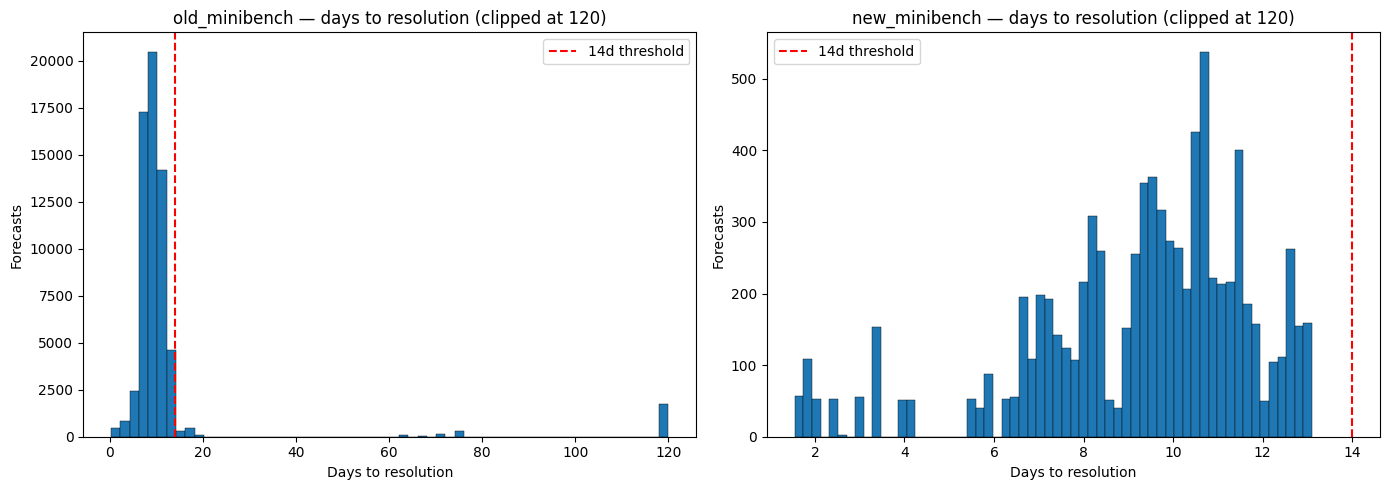

Minibench questions with any forecast > 14d to resolution: 62
  old_minibench: 62
  new_minibench: 0


,url,question_title,minibench_type,duration_days,max_delta,min_delta,n_forecasts,question_open_time,actual_resolve_time
28,https://www.metaculus.com/questions/40640,"Between Oct 1 and Dec 31, 2025 (UTC), will Mal...",old_minibench,50.595,143.759998,143.751033,56,2025-11-11 09:43:54.000000+00,2026-04-04 04:24:20.000000+00
29,https://www.metaculus.com/questions/40641,Will any song credited to Billie Eilish rank i...,old_minibench,50.052,143.227411,143.220700,56,2025-11-11 22:44:25.000000+00,2026-04-04 04:35:40.000000+00
30,https://www.metaculus.com/questions/40643,Will NHC report 16 or more named storms for th...,old_minibench,49.039,142.218817,142.214958,56,2025-11-12 23:04:33.000000+00,2026-04-04 04:23:53.000000+00
31,https://www.metaculus.com/questions/40644,Will the EU/Italy formalize financing or publi...,old_minibench,48.763,141.944031,141.920985,56,2025-11-13 05:41:10.000000+00,2026-04-04 04:24:36.000000+00
34,https://www.metaculus.com/questions/40648,Will the NY Supreme Court (NY County) issue a ...,old_minibench,47.536,141.573700,141.568490,56,2025-11-14 11:08:21.000000+00,2026-04-05 01:22:44.000000+00
...,...,...,...,...,...,...,...,...,...
19,https://www.metaculus.com/questions/40174,Will the community prediction be higher than 8...,old_minibench,15.195,15.183125,15.174023,51,2025-10-01 12:32:15.000000+00,2025-10-16 17:13:10.000000+00
10,https://www.metaculus.com/questions/40129,Will TXN's market close price on 2025-10-16 be...,old_minibench,15.016,15.004327,14.983088,51,2025-10-01 06:26:11.000000+00,2025-10-16 06:49:56.000000+00
8,https://www.metaculus.com/questions/40127,Will FICO's market close price on 2025-10-17 b...,old_minibench,14.242,14.235796,14.231879,51,2025-10-03 12:40:03.000000+00,2025-10-17 18:28:16.000000+00
6,https://www.metaculus.com/questions/40118,"What will be the value of ""ICE BofA High Yield...",old_minibench,14.664,14.099942,14.097016,51,2025-09-30 21:30:34.000000+00,2025-10-15 00:00:00.000000+00


In [17]:
LONG_THRESHOLD_DAYS = 14

mb_forecasts = filtered[filtered["minibench_type"] != "non_minibench"].copy()

# Distribution of days-to-resolution within minibench
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mb_type in zip(axes, ["old_minibench", "new_minibench"]):
    grp = mb_forecasts[mb_forecasts["minibench_type"] == mb_type][_delta_forecast_til_close]
    ax.hist(grp.clip(upper=120), bins=60, edgecolor="k", linewidth=0.3)
    ax.axvline(LONG_THRESHOLD_DAYS, color="red", linestyle="--", linewidth=1.5, label=f"{LONG_THRESHOLD_DAYS}d threshold")
    ax.set_xlabel("Days to resolution")
    ax.set_ylabel("Forecasts")
    ax.set_title(f"{mb_type} — days to resolution (clipped at 120)")
    ax.legend()
plt.tight_layout()
plt.show()

# Questions with any forecast beyond the threshold
mb_long = mb_forecasts[mb_forecasts[_delta_forecast_til_close] > LONG_THRESHOLD_DAYS]

q_summary = (
    mb_long.groupby(["question_id", "post_id", "question_title", "minibench_type", "duration_days"])
    .agg(
        max_delta=(_delta_forecast_til_close, "max"),
        min_delta=(_delta_forecast_til_close, "min"),
        n_forecasts=(_delta_forecast_til_close, "count"),
        question_open_time=("question_open_time", "first"),
        actual_resolve_time=(_actual_resolve_time, "first"),
    )
    .reset_index()
    .sort_values("max_delta", ascending=False)
)
q_summary["url"] = "https://www.metaculus.com/questions/" + q_summary["post_id"].astype(str)

print(f"Minibench questions with any forecast > {LONG_THRESHOLD_DAYS}d to resolution: {len(q_summary)}")
print(f"  old_minibench: {(q_summary['minibench_type'] == 'old_minibench').sum()}")
print(f"  new_minibench: {(q_summary['minibench_type'] == 'new_minibench').sum()}")
display(q_summary[["url", "question_title", "minibench_type", "duration_days", "max_delta", "min_delta", "n_forecasts", "question_open_time", "actual_resolve_time"]])
